# **Upload Dataset**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Salary Data.csv to Salary Data.csv


# **Import Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Dataset**

In [3]:
df = pd.read_csv("Salary Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


# **EDA**

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


# **Data Preprocessing**

In [5]:
#Check Missing Values
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [7]:
#Define Features (X) and Target (y)
X = df.iloc[:, :-1].values   # Years of Experience
y = df.iloc[:, -1].values    # Salary

# **Train Test Split**

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Model Training**

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd # Ensure pandas is available for operations on df

# Handle missing values by dropping rows with any NaN values
df_cleaned = df.dropna()

# Redefine Features (X) and Target (y) using the cleaned DataFrame
X_preprocessed = df_cleaned.iloc[:, :-1]
y_preprocessed = df_cleaned.iloc[:, -1]

# Identify categorical and numerical columns for preprocessing
categorical_cols = X_preprocessed.select_dtypes(include=['object']).columns
numerical_cols = X_preprocessed.select_dtypes(include=np.number).columns

# Create a column transformer to apply one-hot encoding to categorical features
# and pass through numerical features unchanged.
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ],
    remainder='passthrough' # Keep any other columns that are not specified
)

# Apply the preprocessing to X
X_encoded = preprocessor.fit_transform(X_preprocessed)

# Re-perform train-test split with the processed data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_preprocessed, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# **Prediction**

In [11]:
y_pred = model.predict(X_test)

# **Model Evaluation**

In [15]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

R2 Score: 0.85224670950602
MSE: 354250662.5632021
RMSE: 18821.547825914906


# **Visualizations**

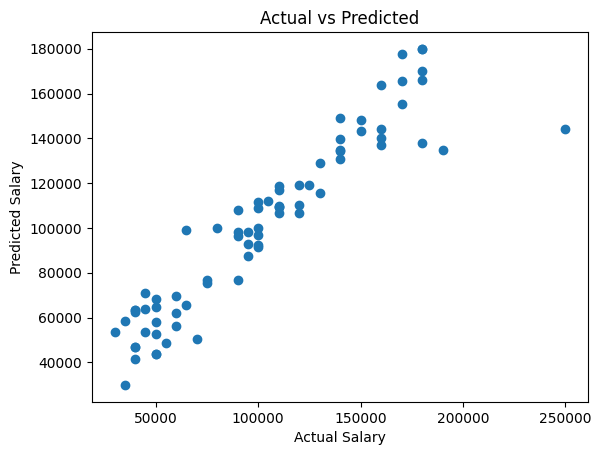

In [17]:
# Actual vs Predicted Plot

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

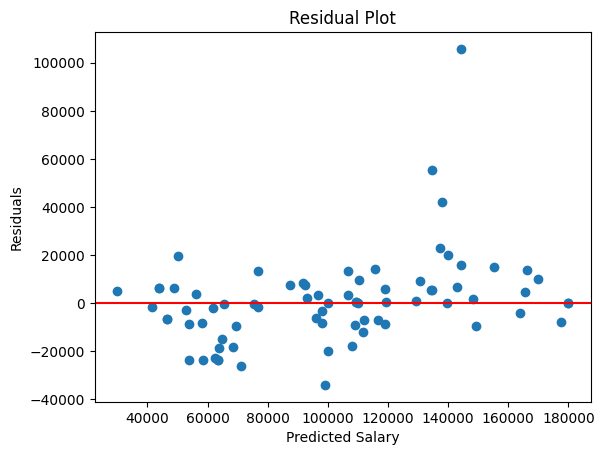

In [18]:
# Residual Plot

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0, color='r')
plt.show()

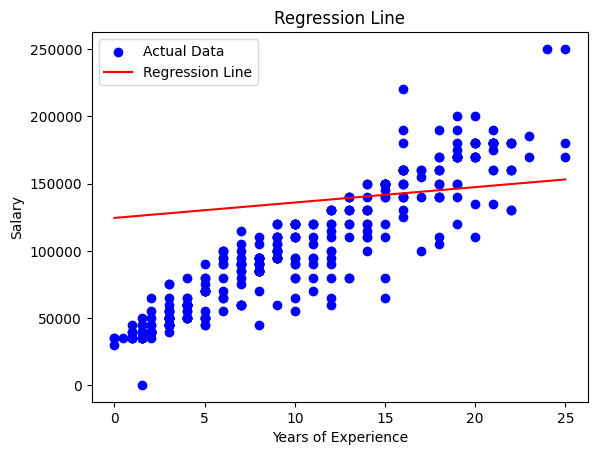

In [22]:
# Scatter Plot + Regression Line

# Get representative values for other features from the cleaned data
gender_mode = df_cleaned['Gender'].mode()[0]
education_mode = df_cleaned['Education Level'].mode()[0]
job_title_mode = df_cleaned['Job Title'].mode()[0]
age_mean = df_cleaned['Age'].mean()

# Create a range of years of experience for plotting the regression line
min_experience = df_cleaned['Years of Experience'].min()
max_experience = df_cleaned['Years of Experience'].max()
experience_range = np.linspace(min_experience, max_experience, 100).reshape(-1, 1)

# Create a DataFrame for prediction, filling in other features with representative values
# The order of columns should match X_preprocessed used during training
predict_df = pd.DataFrame({
    'Age': np.full_like(experience_range.flatten(), age_mean),
    'Gender': np.full_like(experience_range.flatten(), gender_mode, dtype=object),
    'Education Level': np.full_like(experience_range.flatten(), education_mode, dtype=object),
    'Job Title': np.full_like(experience_range.flatten(), job_title_mode, dtype=object),
    'Years of Experience': experience_range.flatten()
})

# Ensure column order matches X_preprocessed from training (this is crucial for preprocessor.transform)
predict_df = predict_df[X_preprocessed.columns]

# Apply the same preprocessing (one-hot encoding) to the prediction DataFrame
X_predict_encoded = preprocessor.transform(predict_df)

# Get predictions from the model
y_predict_line = model.predict(X_predict_encoded)

# Plot the actual data points
plt.scatter(df_cleaned['Years of Experience'], df_cleaned['Salary'], color="blue", label="Actual Data")

# Plot the regression line
plt.plot(experience_range, y_predict_line, color="red", label="Regression Line")

plt.title("Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()